## Import Libraries & Datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Data\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Data Cleaning & Preprocessing

In [3]:
# Drop constant / ID columns
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [4]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(exclude='object').drop('Attrition', axis=1).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [5]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

## Model Training

In [7]:
# Preprocess first to numeric matrix
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_processed, y_train)

In [8]:
# Base learners with class weighting
rf = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)
xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                    scale_pos_weight=len(y_train_res[y_train_res==0])/len(y_train_res[y_train_res==1]),
                    random_state=42)
lgbm = LGBMClassifier(n_estimators=200, max_depth=5, class_weight='balanced', random_state=42)

base_learners = [('rf', rf), ('xgb', xgb), ('lgbm', lgbm)]
meta_learner = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=True
)

# Train on resampled data
stack_model.fit(X_train_res, y_train_res)

[LightGBM] [Info] Number of positive: 986, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8050
[LightGBM] [Info] Number of data points in the train set: 1972, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=5,
                                                       n_estimators=200,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              f...
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=5,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgbm',
                                LGBMClassifier(class_weight='balanced',
                                               max_depth=5, n_estimators=200,
                                               random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   passthrough=True)

In [9]:
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", stack_model)
])
final_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000342 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1156
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'RelationshipSatisfaction',
                                                   'StockOpt...
                                                               max_delta_step=None,
                                                               max_depth=5,
                                                               max_leaves=None,
                                                               min_child_weight=None,
                                                               missing=nan,
                                                               monotone_constraints=None,
                                                               multi_strategy=None,
                                                               n_estimators=200,
                                                               n_jobs=None,
                                                               num_parallel_tree=None, ...)),
                                                ('lgbm',
                                                 LGBMClassifier(class_weight='balanced',
                                                                max_depth=5,
                                                                n_estimators=200,
                                                                random_state=42))],
                                    final_estimator=LogisticRegression(max_iter=1000),
                                    passthrough=True))])

## Model Evaluation

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.59      0.47      0.52        47

    accuracy                           0.86       294
   macro avg       0.75      0.70      0.72       294
weighted avg       0.85      0.86      0.86       294

ROC AUC Score: 0.8118701007838744


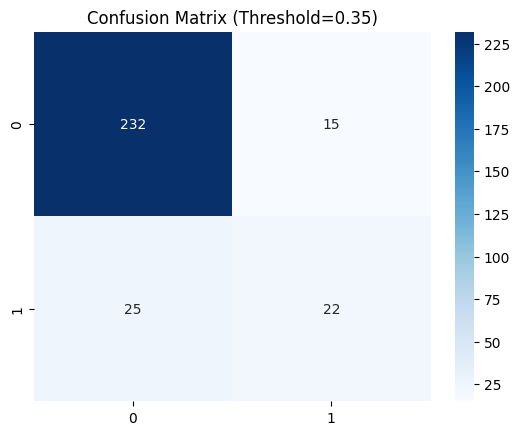

In [10]:
# Predict probabilities
y_proba = stack_model.predict_proba(X_test_processed)[:,1]

# Adjust threshold for better recall
threshold = 0.35
y_pred = (y_proba > threshold).astype(int)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Threshold={threshold})")
plt.show()

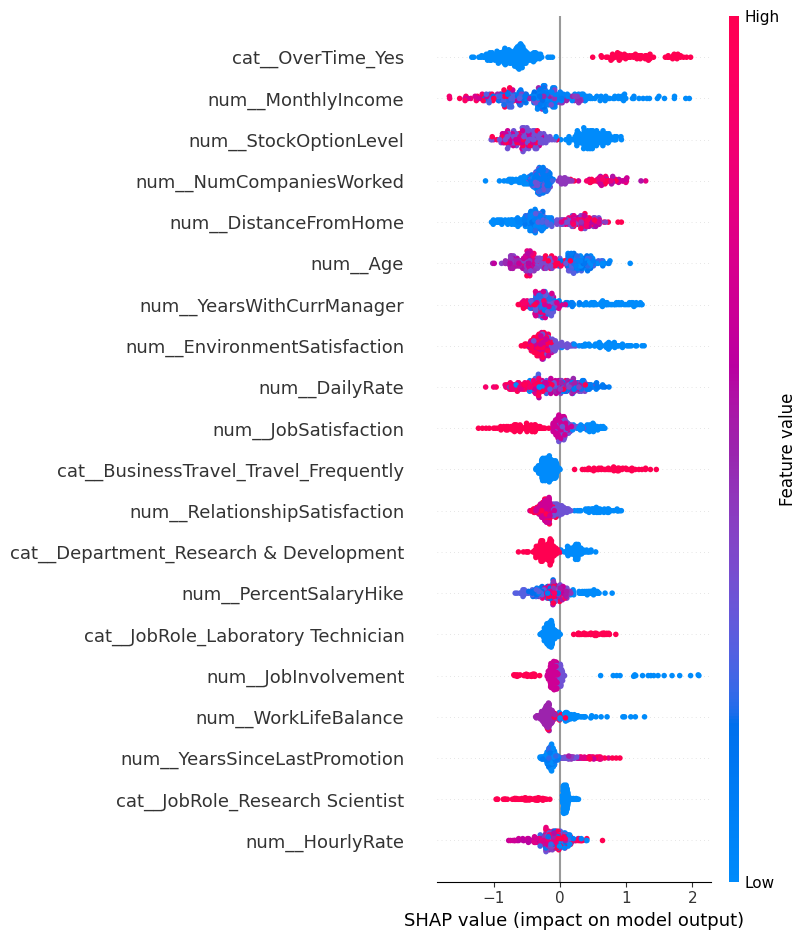

In [11]:
xgb_trained = stack_model.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_trained)
shap_values = explainer.shap_values(X_test_processed)
feature_names = preprocessor.get_feature_names_out()
shap.summary_plot(shap_values, X_test_processed, feature_names=feature_names)

In [12]:
def risk_level(score):
    if score > 0.7:
        return "High"
    elif score > 0.4:
        return "Medium"
    else:
        return "Low"

risk_scores = y_proba
risk_labels = [risk_level(s) for s in risk_scores]

risk_df = X_test.copy()
risk_df['Attrition_Prob'] = risk_scores
risk_df['Risk_Level'] = risk_labels
risk_df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Prob,Risk_Level
1061,24,Non-Travel,830,Sales,13,2,Life Sciences,4,Female,78,...,1,1,2,3,1,0,0,0,0.108725,Low
891,44,Travel_Rarely,1117,Research & Development,2,1,Life Sciences,1,Female,72,...,1,10,5,3,10,5,7,7,0.003559,Low
456,31,Travel_Rarely,688,Sales,7,3,Life Sciences,3,Male,44,...,1,10,3,2,5,4,0,1,0.153959,Low
922,44,Travel_Rarely,1199,Research & Development,4,2,Life Sciences,3,Male,92,...,2,26,4,2,25,9,14,13,0.006607,Low
69,36,Travel_Rarely,318,Research & Development,9,3,Medical,4,Male,79,...,1,2,0,2,1,0,0,0,0.280988,Low


## Extract in `.pkl`

In [13]:
joblib.dump(final_pipeline, "employee_attrition_pipeline.pkl")

['employee_attrition_pipeline.pkl']